
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: D:\environments\anaconda\python.exe -m pip install --upgrade pip


图片形状: torch.Size([32, 3, 32, 32])


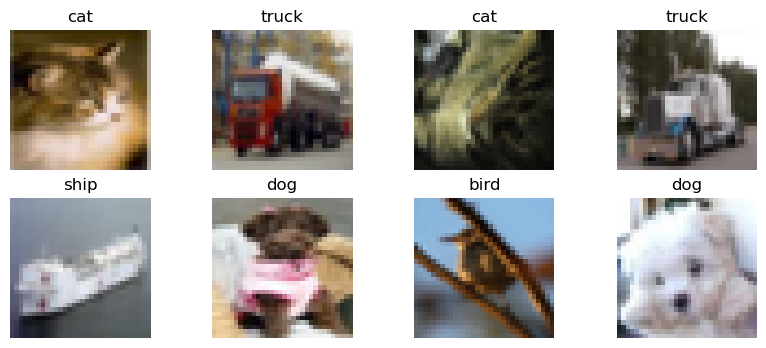

In [11]:
import sys
!{sys.executable} -m pip install tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 归一化到[-1,1]
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

images, labels = next(iter(trainloader))
print(f"图片形状: {images.shape}")  # [32, 3, 32, 32]

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i] / 2 + 0.5  # 从[-1,1]转回[0,1]
    plt.imshow(np.transpose(img.numpy(), (1,2,0)))
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

In [12]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(6)
        
        self.pool = nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(6,16,3, padding = 1)
        self.bn2 = nn.BatchNorm2d(16)
        
        self.conv3 = nn.Conv2d(16,32,3, padding = 1)
        self.bn3 = nn.BatchNorm2d(32)
        
        self.fc1 = nn.Linear(32*8*8, 120)
        self.bn4 = nn.BatchNorm1d(120)
                             
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)


        self.drop = nn.Dropout(0.4)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 32*8*8)
        x = F.relu(self.bn4(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = self.fc3(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR10CNN().to(device)
print(model)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# TensorBoard
writer = SummaryWriter('runs/cifar10_experiment')


sample_images, _ = next(iter(trainloader))
writer.add_graph(model.cpu(), sample_images[:1])
model = model.to(device)

# ===== 训练 =====
epochs = 10  # CIFAR-10需要更多轮数
global_step = 0

for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        global_step += 1
        
        if i % 100 == 99:
            avg_loss = running_loss / 100
            writer.add_scalar('training_loss', avg_loss, global_step)
            print(f'Epoch {epoch+1}, Batch {i+1}, Loss: {avg_loss:.4f}')
            running_loss = 0.0
    
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    writer.add_scalar('test_accuracy', accuracy, epoch)
    print(f'Epoch {epoch+1} 测试准确率: {accuracy:.2f}%')

writer.close()
print('训练完成！')

CIFAR10CNN(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=2048, out_features=120, bias=True)
  (bn4): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (drop): Dropout(p=0.4, inplace=False)
)
Epoch 1, Batch 100, Loss: 2.0262
Epoch 1, Batch 200, Loss: 1.6884
Epoch 1, Batch 300, Loss: 1

In [ ]:
writer = SummaryWriter('runs/mnist_final')